# Selection of the most probable project outcome

In [2]:
import numpy as np #!pip install --upgrade numpy==1.26.4
import pandas as pd
import random
from IPython.core.display import display
import joblib

/var/folders/gm/dmfb8b7n71jgq4nczfq076s40000gn/T/ipykernel_7031/2452624487.py:4: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display


In [3]:
# Data set load
data=pd.read_csv('./data/C201905_counterfactuals/simulation_C201905_counterfactuals__ev0.1812.csv',index_col=0)


# Create a target variable, 'delay' and remove unnecessary columns
data['delay']=(data['actual_duration']>data['baseline_duration'])*1
data.drop(columns=['actual_duration','baseline_duration','critical_path'],inplace=True)
# Sort the columns
columns_sorted = sorted(data.columns, key=lambda x: int(x.replace('duration', '')) if 'duration' in x else float('inf'))
data = data[columns_sorted]
data.head(2)

,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay
0,1738.595774,1967.122966,256.504345,2186.408241,1723.181771,1898.648645,1795.289433,1599.760892,2224.382275,2489.048379,2124.279759,139.271436,8.498099,234.542254,7.655393,1
1,1717.864331,1881.352898,266.048082,2324.022291,1849.728508,2083.309016,1839.782891,1593.929687,2323.598219,2279.745524,2334.495021,145.448900,8.235859,238.908956,8.357302,1


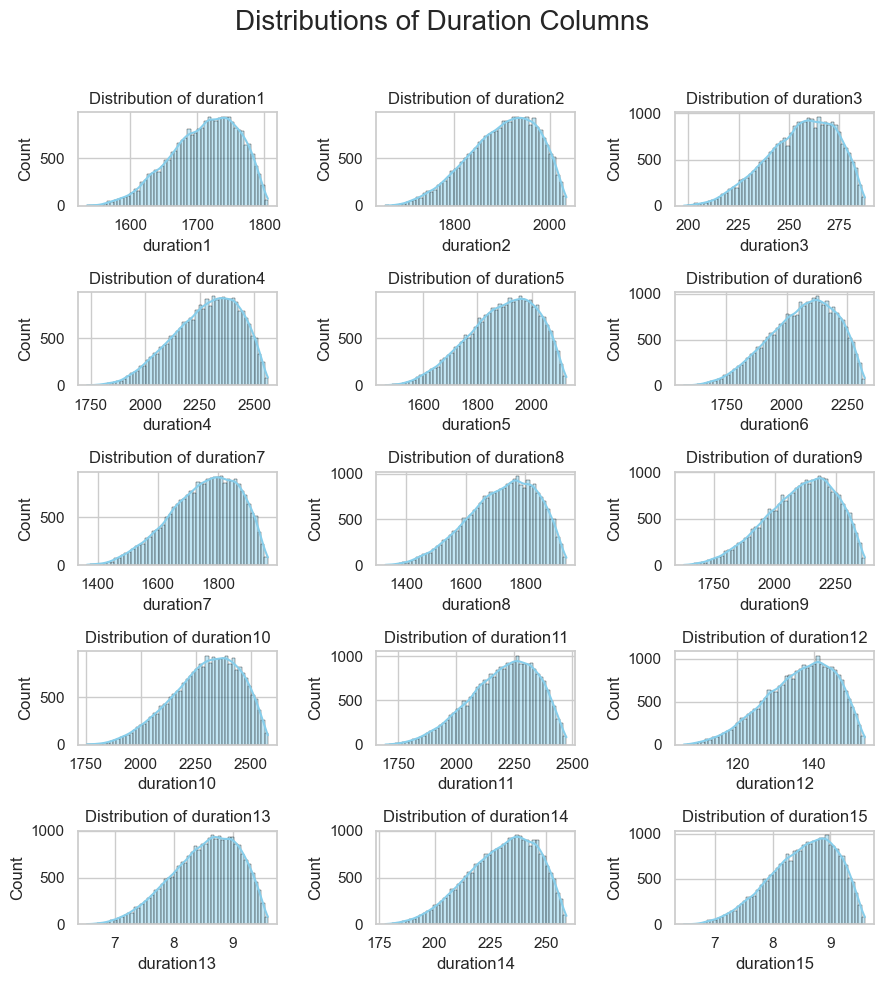

In [17]:

import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# Create a figure with 15 subplots (5 rows x 3 columns)
fig, axes = plt.subplots(5, 3, figsize=(9, 10))
fig.suptitle('Distributions of Duration Columns', fontsize=20)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Loop over the 15 duration columns
for i in range(15):
    col_name = f'duration{i+1}'  # e.g., duration1, duration2, ..., duration15
    ax = axes[i]

    # Plot the distribution using seaborn
    sns.histplot(data[col_name], kde=True, ax=ax, color='skyblue', edgecolor='black')

    # Set the title for each subplot
    ax.set_title(f'Distribution of {col_name}', fontsize=12)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Show the plots
plt.show()


In [19]:
#Most probable value estimation
# Dictionary to store the estimated most probable values
most_probable_values = {}

# Loop over duration columns
for i in range(1, 16):
    col_name = f'duration{i}'
    series = data[col_name].dropna()

    # Compute histogram
    counts, bin_edges = np.histogram(series, bins=30)

    # Find the bin with the highest frequency
    max_bin_index = np.argmax(counts)
    bin_start = bin_edges[max_bin_index]
    bin_end = bin_edges[max_bin_index + 1]
    midpoint = (bin_start + bin_end) / 2

    # Store result
    most_probable_values[col_name] = midpoint

# Create a DataFrame with a single row
probable_df = pd.DataFrame([most_probable_values])

print(probable_df)


     duration1    duration2   duration3    duration4    duration5  \
0  1738.151051  1940.146249  259.205341  2354.586547  1961.244359   

     duration6    duration7    duration8    duration9   duration10  \
0  2110.863516  1795.953357  1766.326231  2183.981493  2372.597386   

    duration11  duration12  duration13  duration14  duration15  
0  2253.745787  141.615307    8.727144  238.726151    8.813169  


In [ ]:
# Asuming durations of task are independent, we can use the mean of the durations as a feature
mean_row_df = pd.DataFrame([data.mean(numeric_only=True)])

# Show the resulting DataFrame
print(mean_row_df)

     duration1    duration2   duration3    duration4    duration5  \
0  1710.693148  1901.873817  256.011923  2279.740053  1892.555295   

     duration6    duration7  duration8   duration9   duration10   duration11  \
0  2064.925171  1754.812101  1724.3481  2107.35224  2295.833817  2201.806482   

   duration12  duration13  duration14  duration15  
0  136.534258     8.53331  230.417194     8.53005  


In [27]:
# Not asuming independence of task

# Define number of hours per working day
hours_per_day = 8

# Create a copy of the original DataFrame
rounded_df = data.copy()

# Select duration columns
duration_cols = [col for col in data.columns if col.startswith('duration')]

# Convert hours to "steps": multiple of working days and round to nearest integer
step_size = 7 #number of working days
# Applying the step to the durations
rounded_df[duration_cols] = (data[duration_cols] / (hours_per_day*step_size)).round(0)

# Show the resulting DataFrame
print(rounded_df)


       duration1  duration2  duration3  duration4  duration5  duration6  \
0           31.0       35.0        5.0       39.0       31.0       34.0   
1           31.0       34.0        5.0       42.0       33.0       37.0   
2           31.0       35.0        5.0       40.0       35.0       31.0   
3           30.0       34.0        5.0       38.0       35.0       37.0   
4           31.0       34.0        5.0       41.0       36.0       37.0   
...          ...        ...        ...        ...        ...        ...   
24995       31.0       35.0        5.0       37.0       33.0       36.0   
24996       31.0       33.0        4.0       44.0       35.0       32.0   
24997       31.0       33.0        5.0       40.0       32.0       37.0   
24998       31.0       34.0        4.0       39.0       30.0       40.0   
24999       30.0       36.0        5.0       43.0       36.0       39.0   

       duration7  duration8  duration9  duration10  duration11  duration12  \
0           32.0     

In [28]:
# count frequency

# Count duplicate rows and reset index to get a DataFrame
df_counts = rounded_df.value_counts().reset_index(name='count')

# Sort by count in descending order
df_counts = df_counts.sort_values(by='count', ascending=False)

# Show the resulting DataFrame
display(df_counts)


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay,cluster,count
0,30.0,36.0,5.0,36.0,35.0,38.0,32.0,29.0,37.0,42.0,41.0,3.0,0.0,4.0,0.0,1,2,2
16650,28.0,33.0,4.0,40.0,34.0,37.0,31.0,31.0,40.0,39.0,35.0,2.0,0.0,4.0,0.0,0,5,1
16672,28.0,30.0,5.0,35.0,38.0,38.0,30.0,29.0,41.0,44.0,40.0,3.0,0.0,4.0,0.0,0,7,1
16671,28.0,30.0,5.0,43.0,34.0,39.0,27.0,29.0,31.0,40.0,39.0,3.0,0.0,4.0,0.0,0,7,1
16670,28.0,31.0,4.0,41.0,32.0,38.0,32.0,34.0,38.0,43.0,42.0,2.0,0.0,4.0,0.0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8331,32.0,36.0,5.0,45.0,37.0,39.0,26.0,32.0,33.0,44.0,38.0,2.0,0.0,4.0,0.0,1,1,1
8330,32.0,36.0,5.0,45.0,37.0,39.0,31.0,27.0,39.0,40.0,41.0,2.0,0.0,4.0,0.0,1,2,1
8329,32.0,36.0,5.0,45.0,35.0,39.0,33.0,31.0,30.0,38.0,38.0,2.0,0.0,4.0,0.0,1,3,1
8328,32.0,36.0,5.0,44.0,36.0,35.0,33.0,29.0,32.0,42.0,38.0,3.0,0.0,4.0,0.0,1,3,1


In [34]:
# Most frequent row
step_row=df_counts.iloc[0, :-1]  # Exclude the count column
step_row_df = pd.DataFrame([step_row], columns=rounded_df.columns)

# Convert most frequent row to hours
step_row_df[duration_cols] = step_row_df[duration_cols] * (hours_per_day*step_size)

# Since step_row_df is not a real instance of the original data, we look for the closest instance in the original data

from scipy.spatial.distance import cdist
import numpy as np

# Calcular distancia euclídea directamente
distances = cdist(data.values, step_row_df.values)

# Índice de la instancia más cercana
closest_index = np.argmin(distances)

# Instancia más cercana
closest_instance = data.iloc[closest_index]
step_closest_instance =  pd.DataFrame([closest_instance], columns=rounded_df.columns)

print("Índice de la instancia más cercana:", closest_index)
print("\nInstancia más cercana:")
print(step_closest_instance)

Índice de la instancia más cercana: 5407

Instancia más cercana:
        duration1    duration2   duration3    duration4    duration5  \
5407  1675.016471  2005.972196  262.054135  1995.297521  1977.653789   

        duration6    duration7   duration8    duration9   duration10  \
5407  2140.386331  1810.384384  1608.22868  2084.835935  2366.136563   

      duration11  duration12  duration13  duration14  duration15  delay  \
5407  2294.46761  150.759503    8.149478  206.077348    7.067476    1.0   

      cluster  
5407      2.0  


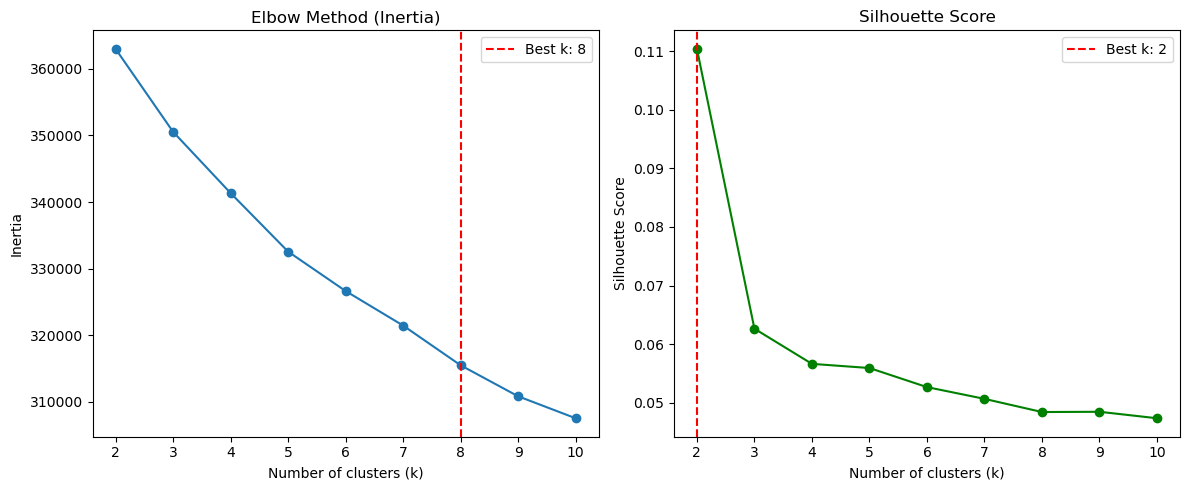

Best k according to silhouette score: 2
Best k according to elbow method (second derivative): 8


In [15]:
## k-means clustering

# select the number of clusters

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Seleccionar columnas numéricas
numeric_cols = data.select_dtypes(include='number').columns
X = data[numeric_cols]

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Rango de k
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Estimar el codo con la "segunda derivada" (curvatura de la inercia)
diffs = np.diff(inertias)
second_diffs = np.diff(diffs)
best_k_elbow = k_range[np.argmin(second_diffs) + 2]  # +2 por dos diferencias sucesivas

# Mejor k por silueta
best_k_silhouette = k_range[np.argmax(silhouette_scores)]

# Graficar
plt.figure(figsize=(12, 5))

# Inercia (Elbow)
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.axvline(x=best_k_elbow, color='red', linestyle='--', label=f'Best k: {best_k_elbow}')
plt.legend()

# Silueta
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.axvline(x=best_k_silhouette, color='red', linestyle='--', label=f'Best k: {best_k_silhouette}')
plt.legend()

plt.tight_layout()
plt.show()

# Imprimir resultados
print(f"Best k according to silhouette score: {best_k_silhouette}")
print(f"Best k according to elbow method (second derivative): {best_k_elbow}")



In [46]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select only numeric columns for clustering (e.g., durations and delay)
numeric_cols = data.select_dtypes(include='number').columns
X = data[numeric_cols]

# Standardize the data for better clustering performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define number of clusters (e.g., 3; can be changed or optimized)
n_clusters = best_k_silhouette  # or best_k_elbow
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
data['cluster'] = kmeans.fit_predict(X_scaled)

# Identify the majority cluster
majority_cluster = data['cluster'].value_counts().idxmax()

# Compute distances to the centroid of the majority cluster
centroid = kmeans.cluster_centers_[majority_cluster]
cluster_data = X_scaled[data['cluster'] == majority_cluster]
distances = np.linalg.norm(cluster_data - centroid, axis=1)

# Get index of the most representative instance (closest to centroid)
representative_index = distances.argmin()
representative_instance = data[data['cluster'] == majority_cluster].iloc[representative_index]

# Show the full DataFrame with cluster assignments
#print(data)

# Show the most representative instance of the majority cluster
print("\nMost representative instance of the majority cluster:")

representative_instance_df=pd.DataFrame([representative_instance])
print(representative_instance_df)



Most representative instance of the majority cluster:
         duration1   duration2   duration3    duration4    duration5  \
11030  1693.727106  1886.06625  257.507414  2353.736811  1883.973101   

        duration6    duration7    duration8    duration9   duration10  \
11030  2140.08145  1804.682241  1730.276268  2111.399063  2327.169221   

        duration11  duration12  duration13  duration14  duration15  delay  \
11030  2295.998461  138.809728    8.609983  219.122919     8.98823    1.0   

       cluster  
11030      1.0  


/var/folders/gm/dmfb8b7n71jgq4nczfq076s40000gn/T/ipykernel_7031/2296467728.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/gm/dmfb8b7n71jgq4nczfq076s40000gn/T/ipykernel_7031/2296467728.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/gm/dmfb8b7n71jgq4nczfq076s40000gn/T/ipykernel_7031/2296467728.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/gm/dmfb8b7n71jgq4nczfq076s40000gn/T/ipykernel_7031/2296467728.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

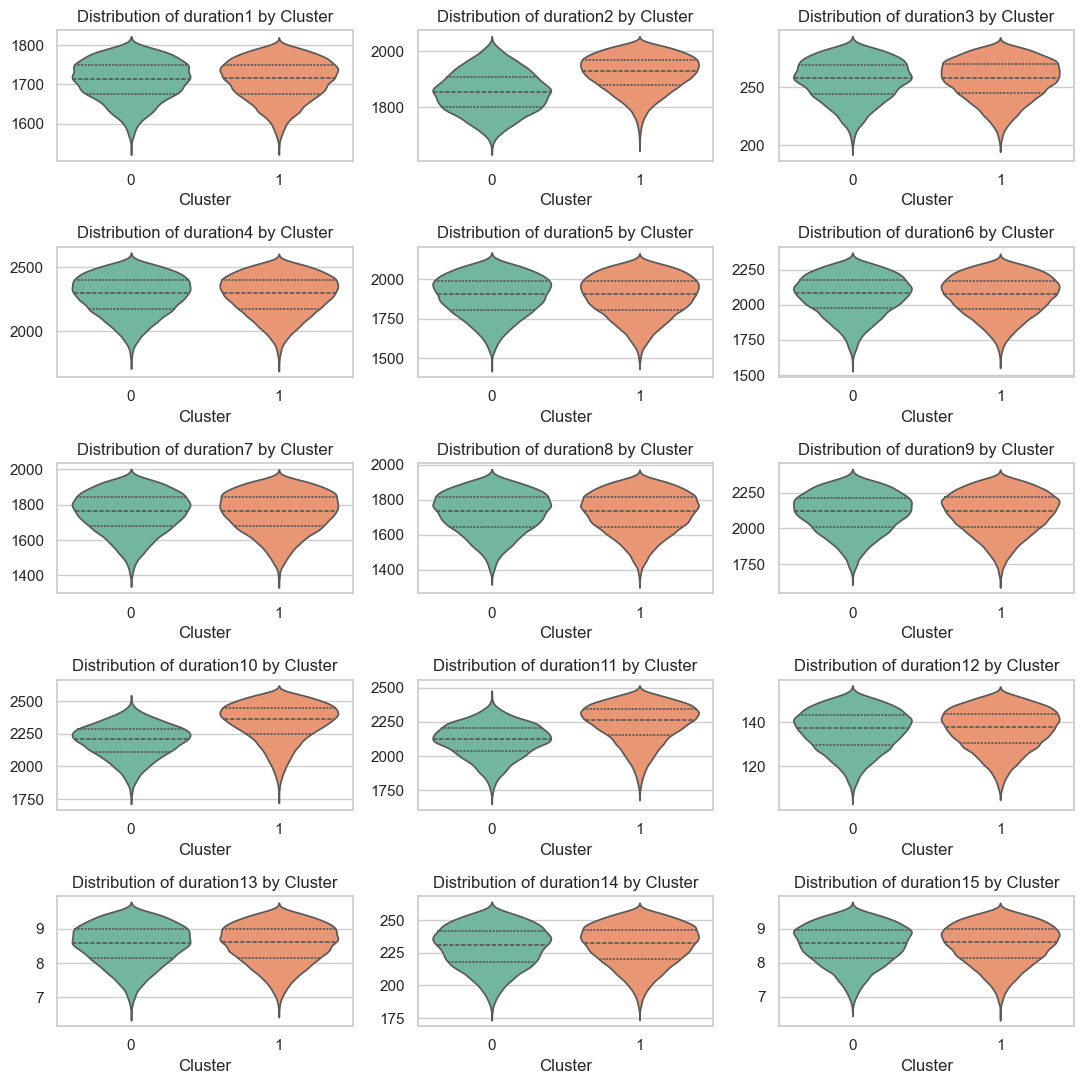

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de las 15 columnas de duración (ajústala si es diferente)
duration_cols = [f'duration{i}' for i in range(1, 16)]

# Crear figura
n_rows = 5
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(11, 11))
axes = axes.flatten()

# Trazar distribución de cada duración por cluster
for i, col in enumerate(duration_cols):
    sns.violinplot(
        data=data,
        x='cluster',
        y=col,
        ax=axes[i],
        palette='Set2',
        inner='quartile'
    )
    axes[i].set_title(f'Distribution of {col} by Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('')

# Ajustar layout
plt.tight_layout()
plt.show()


In [49]:
# print three rows: probable_df, mean_row_df, representative_instance_df
# Concatenate the three DataFrames
result_df = pd.concat([mean_row_df, probable_df, step_closest_instance, representative_instance_df], axis=0)
# Add a column with descriptive strings for each row
result_df['tipo'] = ['media','punto medio barra histograma', 'cernana step', 'cercana centroide']
# Reset index for better display
result_df.reset_index(drop=True, inplace=True)
# Display the concatenated DataFrame
print("\nConcatenated DataFrame:")
display(result_df)


Concatenated DataFrame:


,duration1,duration2,duration3,duration4,duration5,duration6,duration7,duration8,duration9,duration10,duration11,duration12,duration13,duration14,duration15,delay,cluster,tipo
0,1710.693148,1901.873817,256.011923,2279.740053,1892.555295,2064.925171,1754.812101,1724.348100,2107.352240,2295.833817,2201.806482,136.534258,8.533310,230.417194,8.530050,NaN,NaN,media
1,1738.151051,1940.146249,259.205341,2354.586547,1961.244359,2110.863516,1795.953357,1766.326231,2183.981493,2372.597386,2253.745787,141.615307,8.727144,238.726151,8.813169,NaN,NaN,punto medio barra histograma
2,1675.016471,2005.972196,262.054135,1995.297521,1977.653789,2140.386331,1810.384384,1608.228680,2084.835935,2366.136563,2294.467610,150.759503,8.149478,206.077348,7.067476,1.0,2.0,cernana step
3,1693.727106,1886.066250,257.507414,2353.736811,1883.973101,2140.081450,1804.682241,1730.276268,2111.399063,2327.169221,2295.998461,138.809728,8.609983,219.122919,8.988230,1.0,1.0,cercana centroide
